<h1><center> <ins><b> Binomial Option Pricing Model </b></ins></center></h1>

The most simple approach to option pricing is the binomial model. This requires only basic arithmetic and no stochastic calculus. In this model we will see the ideas of hedging and no arbitrage used. The end result is a simple algorithm for determining the correct value for an option.\
We will only look at call options for now to avoid confusion switching between calls and puts, yet all the reasoning and logic follows exactly the same for puts, except we change our payoff function at expiry. This will be explained at the end and implemented into our code.

We will begin by looking at the simplest model for the behaviour of a stock across only 1 time step with zero interest rates. Let us lay out some conditions:
- We will have a stock, and a call option on that stock expiring tomorrow.
- The stock can either rise or fall by a known amount between today and tomorrow.
- Interest rates are zero.

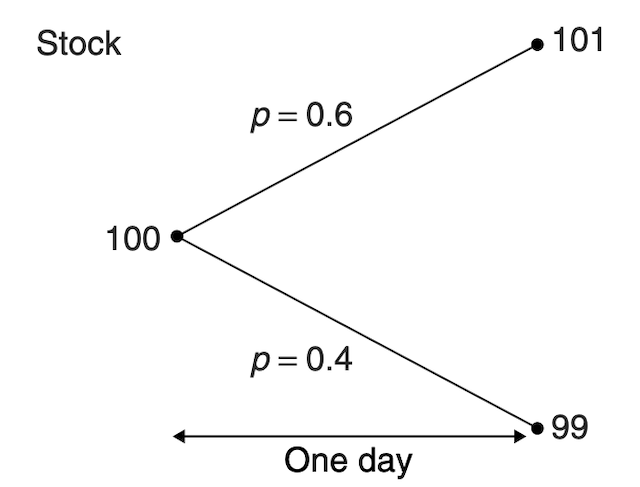

In this case, we will have a stock with a current price of $S=100$. Tomorrow, the option will expire and there is a $60$% chance that the price rises to $101$ and a $40$% chance that the price falls to $99$. Now let us assume we have a call option with a strike price of $K=100$. Let us now consider the value of the option in both cases.\
Recall that the payoff of a call option is $\text{Payoff}=\text{max}\left(S-K,0\right)$.\
If the price of our stock rises to $101$, then the value of the option is: $\,\text{Payoff}=\text{max}\left(101-100,0\right)=1$\
If the price of our stock falls to $99$, then the value of the option is: $\,\text{Payoff}=\text{max}\left(99-100,0\right)=0$

But what is the value of the option originally today?

<h1> <ins>Delta Hedging </ins> </h1>

Now let us attempt to find the value of the option initially. We will construct a **portfolio** made up of one option and we will short $\Delta$ of the underlying stock. Here $\Delta$ denotes the quantity of stock that must be sold for hedging.\
If our stock rises to 101, then the portfolio is worth $1 - 101 \Delta$ where the $1$ being from the option payoff and the $- 101 \Delta$ being from a short (−) position ($\Delta$) in the stock (now worth 101).\
Similarly if the stock falls to 99, then the portfolio is worth $0 - 99 \Delta$.\
Now we will make both of these equal to each other to find the value of $\Delta$.\
So, $1 - 101 \Delta = 0 - 99 \Delta \implies 2 \Delta = 1 \iff \Delta = \frac{1}{2}$\
Now regardless of if the stock went up or down tomorrow, the portfolio will be worth $-\frac{99}{2}$. Since, we have assumed interest rates are zero, our portfolio must have been worth the same today. This is the principle of **no arbitrage**. Therefore, letting $V$ denote the option value today,
$$V - \frac{1}{2}\times 100 = 1 - \frac{1}{2}\times 101 = -\frac{99}{2}$$
$$ \implies V = -\frac{99}{2} + \frac{100}{2} = \frac{1}{2}$$

Interestingly, if we look back at our calculations, we can see that we never used our probabilities of our stock going up or down. This is equivalent to saying that the stock growth chance is irrelevant for option pricing. This is because we have **hedged** the option with the stock.\
**Delta hedging** means choosing $\Delta$ such that the portfolio value does not depend on the direction of the stock.

<h1> <ins> Non-zero interest rates</h1> </ins>

Let us take the discrete interest rate $r=0.1$.\
Taking all other parameters to be the same as before, let us consider the same portfolio. Since we are working on a one day time step, $\text{Today's Portfolio} \times \left(1+\frac{0.1}{252}\right) = \text{Tomorrow's Portfolio}$. And using our principle of **no arbitrage** earlier, we can conclude that
$$ \left(V - \frac{1}{2}\times 100\right) \times \left(1+\frac{0.1}{252}\right) = 1 - \frac{1}{2}\times 101 = -\frac{99}{2}$$
$$ \implies V = \left(-\frac{99}{2} \times \frac{2520}{2521}\right) + \frac{100}{2} \approx 0.52$$

<h1> <ins>Generalising One Period Binomial Models</h1> </ins>

Let us consider an underlying asset $S$ originally at time $t=0$ that after a time step of $\delta t$ to $t=\delta t$, can either
- increase by a factor of $u$ (up) to a value of $u\,S$ with a probability of $p$ or
- decrease by a factor of $d$ (down) to a value of $d\,S$ with a probability of $1-p$

such that $0 < d < u $ and $0 < p < 1$.\
We can visualise this as below:

### Fig. 1
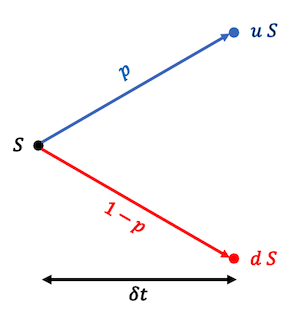

<h1> <ins>No-Arbitrage</h1> </ins>

Now we understand, from our basic example above, the dynamics of an underlying asset, let us state an important condition. It is the **no-arbitrage** condition that:
$$ d < 1+r < u$$
where r is the risk-free interest rate.

To make sense of this, let us assume that $d \ge 1+r$. Then the underlying asset, even in the worst case, would do better than what we could earn with risk-free assets. So we would have an **arbitrage**. Starting with zero wealth, we would borrow money and simply buy the stock. We are guaranteed to make money, since the value of our stock would increase faster than our debt increases. So either way, we can repay our debt while benefiting from the difference.\
Similarly, if $u \le 1+r$, we would have an **arbitrage**. Starting with zero wealth, we borrow money, sell the stock short, and put the proceeds into the money market. Even in the worst case for us, the stock will only go up to $u\,S$, which is less than what we would make on interest on our loan. So again we would benefit from this.

Hence to avoid these cases, we must have the condition $ d < 1+r < u$.

<h1> <ins>Parameters 1</h1> </ins>

Now we need our $u,\,d\,\text{and}\,p$ to give the binomial walk the same drift $(\mu)$ and standard deviation $(\sigma)$ as the asset we are trying to model since in reality, these are the only 2 values we can evaluate for, given enough information about an underlying asset. Although there are infinite ways to do this, we will consider the following:
$$u = 1 + \sigma\,\sqrt{\delta t} \tag{1}$$
$$d = 1 - \sigma\,\sqrt{\delta t} \tag{2}$$
$$p = \frac{1}{2} + \frac{\mu\,\sqrt{\delta t}}{2\sigma} \tag{3}$$ <br>
In order to show that these work, let us consider the average asset change and the standard deviation of asset change.\
The average asset change is
$$p\,u\,S + (1-p)\,d\,S = \left(\frac{1}{2} + \frac{\mu\,\sqrt{\delta t}}{2\sigma}\right)\left(1 + \sigma\,\sqrt{\delta t}\right)\,S + \left(1-\left(\frac{1}{2} + \frac{\mu\,\sqrt{\delta t}}{2\sigma}\right)\right)\,\left(1 - \sigma\,\sqrt{\delta t}\right)\,S$$
$$= S\left[\left(\frac{1}{2} + \frac{\mu\,\sqrt{\delta t}}{2\sigma}\right)\left(1 + \sigma\,\sqrt{\delta t}\right) + \left(\frac{1}{2} - \frac{\mu\,\sqrt{\delta t}}{2\sigma}\right)\,\left(1 - \sigma\,\sqrt{\delta t}\right)\right]$$
$$=S\left(\frac{1}{2}+\frac{1}{2}+\frac{\sigma\,\sqrt{\delta t}}{2}-\frac{\sigma\,\sqrt{\delta t}}{2}+\frac{\mu\,\sqrt{\delta t}}{2\sigma}-\frac{\mu\,\sqrt{\delta t}}{2\sigma}+\frac{\mu\,\delta t}{2}+\frac{\mu\,\delta t}{2}\right)$$
$$=S\left(1+\mu\,\delta t\right)$$
Therefore, the expected return is $\mu\,\delta t$, which is correct.

Now let us recall that for a discrete random variable $X$ over sample space $S$,
$$\text{Var}\left(X\right) = \sum_{x \in S} \left[P\left(X=x\right)\left(x-\bar{x} \right)^{2}\right]$$
Thus, the variance of asset change is
$$ p\,\left(u\,S-S\left(1+\mu\,\delta t\right)\right)^{2}+\left(1-p\right)\left(d\,S-S\left(1+\mu\,\delta t\right)\right)^{2}$$
$$=S^{2}\left[p\,\left(u-1-\mu\,\delta t\right)^{2}+\left(1-p\right)\left(d-1-\mu\,\delta t\right)^{2}\right] $$
Using (1),(2) and (3) from above,
$$=S^{2}\left[p\,\left(\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}+\left(1-p\right)\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}\right] $$
$$=S^{2}\left[p\,\left(\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}-p\,\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}+\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}\right] $$
$$=S^{2}\left[-4p\,\mu\,\sigma\,\sqrt{\delta t}\,\delta t+\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}\right] $$
$$=S^{2}\left[-4\mu\,\sigma\,\sqrt{\delta t}\,\delta t\left(\frac{1}{2} + \frac{\mu\,\sqrt{\delta t}}{2\sigma}\right)+\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}\right] $$
$$=S^{2}\left[-2\mu\,\sigma\,\sqrt{\delta t}\,\delta t - 2\mu^{2}\left(\delta t\right)^{2} +\left(-\sigma\,\sqrt{\delta t}-\mu\,\delta t\right)^{2}\right] $$
$$=S^{2}\left[-2\mu\,\sigma\,\sqrt{\delta t}\,\delta t +2\mu\,\sigma\,\sqrt{\delta t}\,\delta t + \sigma^{2}\delta t - 2\mu^{2}\left(\delta t\right)^{2} + \mu^{2}\left(\delta t\right)^{2}\right] $$
$$=S^{2}\left(\sigma^{2}\delta t - \mu^{2}\left(\delta t\right)^{2}\right) $$
$$=S^{2}\sigma^{2}\delta t\left(1 - \left(\frac{\mu}{\sigma}\right)^{2}\delta t\right) $$
$$\approx S^{2}\sigma^{2}\delta t$$\
Therefore, the standard deviation of asset change is approximately $\sqrt{S^{2}\sigma^{2}\delta t} = S\,\sigma\sqrt{\delta t}$.\
And so, the standard deviation of returns is approximately $\sigma\sqrt{\delta t}$, which is correct.

<h1> <ins>Finding the price of an option</h1> </ins>

Suppose we know the value of the option at the time $t=\delta t$. Let us construct a portfolio, $\Pi$, at time $t=0$ made up of one option and a short position in a quantity $\Delta$ of the underlying asset. Thus,
$$\Pi = V - \Delta\,S \tag{4}$$ where V is the value of the option at time $t=0$ and S is the price of the underlying asset at time $t=0$.\
At time $t=\delta t$, the price of the asset will either go up to $uS$ or down to $dS$ and the option can either have a value of $V^{+}$ or $V^{-}$ depending on if it went up or down respectively.\
Thus the portfolio will increase or decrease to $V^{+} - \Delta\,u\,S$ or $V^{-} - \Delta\,d\,S$.
As before, we will **delta hedge** this, so we can say
$$V^{+} - \Delta\,u\,S = V^{-} - \Delta\,d\,S$$\
$$\implies \Delta\,S\left(u-d\right) = V^{+}-V^{-}$$\
$$\implies \Delta = \frac{V^{+}-V^{-}}{S\left(u-d\right)}$$
Therefore, our portfolio at time $t=\delta t$ will be either:
- $V^{+} - \frac{V^{+}-V^{-}}{S\left(u-d\right)}\,u\,S = V^{+} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}$, if the asset goes up
- $V^{-} - \frac{V^{+}-V^{-}}{S\left(u-d\right)}\,d\,S = V^{-} - \frac{d\left(V^{+}-V^{-}\right)}{u-d}$, if the asset goes down\
Due to our delta hedging we can say $V^{+} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}=V^{-} - \frac{d\left(V^{+}-V^{-}\right)}{u-d}$

Now by the principle of **no arbitrage**, this value must be equal to value of the original portfolio plus any interest earned at the risk-free rate. So,
$$\Pi \left(1+r\delta t\right) = V^{+} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}$$
By substituting our portfolio equation in (4),
$$\left(1+r\delta t\right)\left(V - \Delta\,S\right) = \left(1+r\delta t\right)\left(V - S\frac{V^{+}-V^{-}}{S\left(u-d\right)}\right) = V^{+} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}$$\
$$\left(1+r\delta t\right)\,V = \left(1+r\delta t\right)\frac{V^{+}-V^{-}}{u-d} + \frac{V^{+}\left(u-d\right)}{u-d} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}$$\
$$= \left(1+r\delta t\right)\frac{V^{+}-V^{-}}{u-d} + \frac{u\,V^{-} - dV^{+}}{u-d}$$\
Now let us substitute (1) and (2) into this,
$$\left(1+r\delta t\right)\,V = \left(1+r\delta t\right)\frac{V^{+}-V^{-}}{2\sigma \sqrt{\delta t}} + \frac{V^{-}\left(1+\sigma \sqrt{\delta t}\right) - V^{+}\left(1-\sigma \sqrt{\delta t}\right)}{2\sigma \sqrt{\delta t}}$$
$$= \frac{1}{2\sigma \sqrt{\delta t}}\left[V^{+}\left(1+r\delta t\right)-V^{-}\left(1+r\delta t\right)+V^{-}\left(1+\sigma \sqrt{\delta t}\right)-V^{+}\left(1-\sigma \sqrt{\delta t}\right) \right]$$
$$= \frac{1}{2\sigma \sqrt{\delta t}}\left[V^{+}\left(\sigma \sqrt{\delta t}+r\delta t\right)+V^{-}\left(\sigma \sqrt{\delta t}-r\delta t\right)\right]$$
$$= V^{+}\left(\frac{\sigma \sqrt{\delta t}+r\delta t}{2\sigma \sqrt{\delta t}}\right)+V^{-}\left(\frac{\sigma \sqrt{\delta t}-r\delta t}{2\sigma \sqrt{\delta t}}\right)$$
$$= V^{+}\left(\frac{1}{2}+\frac{r\sqrt{\delta t}}{2\sigma}\right)+V^{-}\left(\frac{1}{2}-\frac{r\sqrt{\delta t}}{2\sigma}\right)$$
Note that $1-\left(\frac{1}{2}+\frac{r\sqrt{\delta t}}{2\sigma}\right) = \frac{1}{2}-\frac{r\sqrt{\delta t}}{2\sigma}$. So,
$$ \left(1+r\delta t\right)\,V = p'V^{+} + \left(1-p'\right)V^{-}$$
where $p'=\frac{1}{2}+\frac{r\sqrt{\delta t}}{2\sigma}$
$$\implies V = \frac{1}{1+r\delta t}\left(p'V^{+} + \left(1-p'\right)V^{-}\right)$$

Let us take a look at this equation in detail and recall our earlier defined real probability of a stock rise, $p$ in (3). Suppose instead of $p'$, our right hand side expression contained this $p$. Then this expression would be the expected value at the next time step. Now, we know that the probability of a rise or fall is irrelevant as far as option pricing is concerned since $p$ did not appear in equation. Yet what would happen if we interpret $p'$ as a probability? Then we could say that the option price is the present value of an expectation, but not the real expectation.\
This leads us to **risk-neutral** expectations.\
Note how, $p'$ is exactly the same as $p$ if we replace $r$ with $\mu$.

So let us call $p'$ the **risk-neutral probability**.

<h1> <ins>How do we choose the parameters though?</h1> </ins>

The question now arises as to how we choose our parameters $u,\,d\,\text{and}\,p$. There are infinitely many ways to do so and as shown above, they may be good approximations but not exactly what we are looking for.\
In order to avoid this for now, let us consider the case where we do not need to go about this. We will instead assume that we are working with the exact given values of $u,\,d\,\text{and}\,p$. Now obviously, this is not as helpful in reality since we would only be able to infer volatility and interest rates. Yet, let us consider this as a stepping stone to better understand this model.

<h1> <ins>Alternative method</h1> </ins>

As before, we will use the same model shown and explained in Figure 1. As explained before, we will construct the same portfolio as in (4), $\Pi = V - \Delta\,S$. By the reasoning shown there, we know $\Delta = \frac{V^{+}-V^{-}}{S\left(u-d\right)}$.
<br>
Now this time, instead of substituting our predefined values for $u,\,d\,\text{and}\,p$ in terms of $\mu\,\text{and}\,\sigma$, we can say, by the principle of no-arbitrage, our portfolio at time $\delta t$ is
$$\Pi(1+r\delta t) = V^{+} - \Delta\,u\,S = V^{+} - \frac{V^{+}-V^{-}}{S\left(u-d\right)}u\,S = V^{+} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}$$
So,
$$\Pi=\frac{1}{1+r\delta t}\left(\frac{V^{+}(u-d)}{u-d} - \frac{u\left(V^{+}-V^{-}\right)}{u-d}\right)$$
$$=\frac{uV^{-}-dV^{+}}{\left(1+r\delta t\right)\left(u-d\right)}$$
<br>
Now going back to our original equation in (4), we can substitute the values of $\Delta$ and $\Pi$ into this to find $V$, our value of the option at time $t=0$,
$$V=\Delta\,S + \Pi = \frac{V^{+}-V^{-}}{S\left(u-d\right)}S + \frac{uV^{-}-dV^{+}}{\left(1+r\delta t\right)\left(u-d\right)}$$
<br>
$$=\frac{V^{+}-V^{-}}{u-d} + \frac{uV^{-}-dV^{+}}{\left(1+r\delta t\right)\left(u-d\right)}$$
<br>
$$=\frac{\left(1+r\delta t\right)\left(V^{+}-V^{-}\right)+uV^{-}-dV^{+}}{\left(1+r\delta t\right)\left(u-d\right)}$$
<br>
$$=\frac{1}{1+r\delta t}\left[\frac{\left(1+r\delta t\right)-d}{u-d}V^{+} + \frac{u-\left(1+r\delta t\right)}{u-d}V^{-}\right]$$
<br>
Again, note that $1-\frac{\left(1+r\delta t\right)-d}{u-d} = \frac{(u-d)-\left(1+r\delta t\right)-d}{u-d} = \frac{u-\left(1+r\delta t\right)}{u-d}$. So,
$$\boxed{V = \frac{1}{1+r\delta t}\left(\bar{p}V^{+} + \left(1-\bar{p}\right)V^{-}\right)} \tag{5}$$
$$\text{where}\,\,\bar{p} = \frac{\left(1+r\delta t\right)-d}{u-d}$$

As explained above, we can take $\bar{p}$ to be the **risk-neutral probability**

<h1> <ins>Multi-period Binomial Model</h1> </ins>

Now let us consider a model with multiple time periods and continuous interest rates.
So we can say for a given portfolio at time ($\Pi_{t}$) and an interest rate of $r$, $\Pi_{t+\delta t} = \Pi_{t}e^{r\delta t}$.

Let us again consider an underlying asset $S$ originally at time $t=0$ that after 2 time steps of $\delta t$, can either
- increase by a factor of $u$ (up) **twice** to a value of $u^{2}\,S$ with a probability of $p^{2}$ or
- decrease by a factor of $d$ (down) **twice** to a value of $d^{2}\,S$ with a probability of $(1-p)^{2}$ or
- increase by a factor of $u$ (up) then decrease by a factor of $d$ (down), in either order, to a value of $ud\,S$ with a probability of $p\,(1-p)$

Again, by the principle of **no-arbitrage** explained eariler, we must have the condition that $d < e^{r\delta t} < u$.\
Thus we must have $0 < d < e^{r\delta t} < u$ and $0 < p < 1$.

Now let us visualise this model for ease of understanding.

### Fig. 2
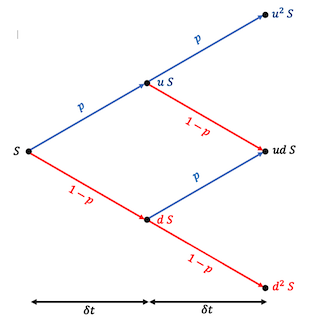

This model shows how the price of an underlying asset S would change across 2 time periods.

Now let us introduce some new notation. Let us denote $V_{i}$ for $ i \in \{u^{\alpha}d^{\beta}: \alpha,\beta \in \mathbb{N}^{\ge 0}\}$ as the value of a call option after $\alpha$ up movements and $\beta$ down movements. Also, we will let $V_{0}=V$.

We know the price of a call option at time $t=2\delta t$ since we are assuming that this is at expiry. By recalling that the payoff of a call option at expiry is $\text{max}\left(S-K,0\right)$, we can say
- $V_{uu} = \text{max}\left(u^{2}S-K,0\right)$
- $V_{ud} = \text{max}\left(ud\,S-K,0\right)$
- $V_{dd} = \text{max}\left(d^{2}S-K,0\right)$

As derived when we looked at a single time period model, from (5), adjusting for continuous interest rates, and by working backwards from our known values of $V_{uu}, V_{ud}\,\text{and}\,V_{dd}$, we can say that

$$V_{u} = e^{-r\delta t}\left(\bar{p}V_{uu} + \left(1-\bar{p}\right)V_{ud}\right)$$\
$$V_{d} = e^{-r\delta t}\left(\bar{p}V_{ud} + \left(1-\bar{p}\right)V_{dd}\right)$$\
$$\text{where}\,\,\bar{p} = \frac{e^{r\delta t}-d}{u-d} \tag{6}$$\
Now let us work backwards along our tree once more to find the value of our call option at time $t=0$ ($V$). We will get,

$$V=e^{-r\delta t}\left(\bar{p}V_{u} + \left(1-\bar{p}\right)V_{d}\right)$$\
$$=e^{-r\delta t}\left[\bar{p}\left(e^{-r\delta t}\left(\bar{p}V_{uu} + \left(1-\bar{p}\right)V_{ud}\right)\right) + \left(1-\bar{p}\right)\left(e^{-r\delta t}\left(\bar{p}V_{ud} + \left(1-\bar{p}\right)V_{dd}\right)\right)\right]$$\
$$=e^{-2r\delta t}\left[\bar{p}\left(\bar{p}V_{uu} + \left(1-\bar{p}\right)V_{ud}\right) + \left(1-\bar{p}\right)\left(\bar{p}V_{ud} + \left(1-\bar{p}\right)V_{dd}\right)\right]$$\
$$V=e^{-2r\delta t}\left[\left(\bar{p}\right)^{2}V_{uu} + 2\bar{p}\left(1-\bar{p}\right)V_{ud} + \left(1-\bar{p}\right)^{2}V_{dd}\right] \tag{7}$$

Now let us consider a model with 3 time periods but with all of the same conditions and parameters. Again, we know the values of $V_{i}$ for $ i \in \{u^{\alpha}d^{\beta}: \alpha,\beta =0,1,2,3\,\,\text{and}\,\,\alpha + \beta = 3\}$, since this occurs at expiry and we can use our payoff function defined above. By the same logic used above, we can say

$$V_{uu} = e^{-r\delta t}\left(\bar{p}V_{uuu} + \left(1-\bar{p}\right)V_{uud}\right)$$\
$$V_{ud} = e^{-r\delta t}\left(\bar{p}V_{uud} + \left(1-\bar{p}\right)V_{udd}\right)$$\
$$V_{dd} = e^{-r\delta t}\left(\bar{p}V_{udd} + \left(1-\bar{p}\right)V_{ddd}\right)$$
Now we can substitute this into (7) to find the value of the option at time $t=0$,

$$V=e^{-2r\delta t}\left[\left(\bar{p}\right)^{2}V_{uu} + 2\bar{p}\left(1-\bar{p}\right)V_{ud} + \left(1-\bar{p}\right)^{2}V_{dd}\right]$$\
$$=e^{-2r\delta t}\left[\left(\bar{p}\right)^{2}\left(e^{-r\delta t}\left(\bar{p}V_{uuu} + \left(1-\bar{p}\right)V_{uud}\right)\right) + 2\bar{p}\left(1-\bar{p}\right)\left(e^{-r\delta t}\left(\bar{p}V_{uud} + \left(1-\bar{p}\right)V_{udd}\right)\right) + \left(1-\bar{p}\right)^{2}\left(e^{-r\delta t}\left(\bar{p}V_{udd} + \left(1-\bar{p}\right)V_{ddd}\right)\right)\right]$$\
$$=e^{-3r\delta t}\left[\left(\bar{p}\right)^{2}\left(\bar{p}V_{uuu} + \left(1-\bar{p}\right)V_{uud}\right) + 2\bar{p}\left(1-\bar{p}\right)\left(\bar{p}V_{uud} + \left(1-\bar{p}\right)V_{udd}\right) + \left(1-\bar{p}\right)^{2}\left(\bar{p}V_{udd} + \left(1-\bar{p}\right)V_{ddd}\right)\right]$$\
$$V=e^{-3r\delta t}\left[\left(\bar{p}\right)^{3}V_{uuu} + 3\left(\bar{p}\right)^{2}\left(1-\bar{p}\right)V_{uud} + 3\bar{p}\left(1-\bar{p}\right)^{2}V_{uud} + \left(1-\bar{p}\right)^{3}V_{ddd}\right] \tag{8}$$

Upon inspecting (7) and (8) closer, we can clearly see how the terms resemble a **binomial expansion**. This makes sense intuitively since within our model, the price of an underlying asset can either go up or down each time step. We can similarly think of this as flipping a coin each time step and noting if we are getting a heads or tails. Clearly we can say that 
- The number of time steps is fixed
- Each observation is independent
- Each observation represents one of two outcomes (increase in price or decrease in price)
- The probability of an increase ($p$) is the same for each time step

Thus, we can say that our model fits a **binomial distribution**.

We can now think of a model with $n$ time steps each of length $\delta t$. By the logic above, we can find the general formula for the price of a call option at time $t=0$ to be
$$V = e^{-nr\delta t}\left[\sum_{j=0}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}V_{i}\right]$$
$$\text{where}\,\,i = u^{j}d^{n-j}$$

To make this neater, we can write $V_{i}$ in terms of the Payoff function since all the terms only contain values of the option at expiry. With this we can say
$$V = e^{-nr\delta t}\left[\sum_{j=0}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\,\text{max}\{u^{j}d^{n-j}S-K,0\}\right] \tag{9}$$
Of course, we have not proved this rigorously, yet it is trivial to do so by weak induction so we will move forwards by attempting to simplify this a bit.

To begin with, let us denote $a$ as the **minimum** number of upward moves the underlying asset takes over $n$ time periods for the call option to end **in-the-money**. For this to occur we require $V_{i} > 0$. Using our payoff function we can say
$$\text{max}\{u^{j}d^{n-j}S-K,0\} > 0$$\
$$\implies u^{j}d^{n-j}S-K > 0$$\
$$\implies u^{j}d^{n-j}S>K$$
Thus, $$a = \text{min}\{0 \le x \le n\,:\,u^{x}d^{n-x}S > K\}\,\,\text{, where x} \in \mathbb{N}^{\ge 0}$$

To find this value of $a$ we simply solve the inequality $u^{a}d^{n-a}S > K$ in terms of $a$ as follows
$$\ln{\left(u^{a}d^{n-a}S\right)} > \ln{(K)} $$
$$\implies a\,\ln{(u)}+(n-a)\ln{(d)}+\ln{(S)} > \ln{(K)} $$
$$\implies a\left(\ln{\left(\frac{u}{d}\right)}\right) > \ln{\left(\frac{K}{Sd^{n}}\right)}$$
$$\implies a > \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}} \tag{10}$$

So we can say for any $x < a$, $V_{i} = 0$. Now let us look back at our summation expression for $V$ in (9).

We can remove the values of $j < a$ since these values are simply 0. This means that for all $j$ with this restriction, $\text{max}\{u^{j}d^{n-j}S-K,0\} = u^{j}d^{n-j}S-K$. So,
$$V = e^{-nr\delta t}\left[\sum_{j=a}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\,\left(u^{j}d^{n-j}S-K\right)\right]$$

Now let us separate the right hand side into 2 terms. We can say
$$V = e^{-nr\delta t}\left[S\left(\sum_{j=a}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\,\left(u^{j}d^{n-j}\right)\right) - K\left(\sum_{j=a}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\right)\right]$$
$$V = e^{-nr\delta t}\left[S\left(\sum_{j=a}^{n}\binom{n}{j}\left(u\bar{p}\right)^{j}\left[d\left(1-\bar{p}\right)\right]^{n-j}\right) - K\left(\sum_{j=a}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\right)\right] \tag{11}$$

The term on the right involving $K$ includes only the **risk-neutral** probability we talked about earlier. But the left term involving $S$ still contains $u$ and $d$ inside the summation, so it is not in this form yet. Let us investigate this term.
$$Se^{-nr\delta t}\left(\sum_{j=a}^{n}\binom{n}{j}\left(u\bar{p}\right)^{j}\left[d\left(1-\bar{p}\right)\right]^{n-j}\right) = Se^{-jr\delta t}e^{-(n-j)r\delta t}\left(\sum_{j=a}^{n}\binom{n}{j}\left(u\bar{p}\right)^{j}\left[d\left(1-\bar{p}\right)\right]^{n-j}\right)$$
$$=S\left(\sum_{j=a}^{n}\binom{n}{j}\left(\frac{u}{e^{r\delta t}}\bar{p}\right)^{j}\left[\frac{d}{e^{r\delta t}}\left(1-\bar{p}\right)\right]^{n-j}\right)$$

Consider the price of an underlying asset in a **risk-netural** world. In this case, the value of the underlying asset invested in a risk-free asset is equivalent to the value of the stock invested in the market. So using our earlier defined risk-netural probability $\bar{p}$, $$e^{r\delta t}S = u\bar{p}S + d(1-\bar{p})S$$
This can then be changed by dividing by $e^{r\delta t}S$ to get
$$\frac{u}{e^{r\delta t}}\bar{p} + \frac{d}{e^{r\delta t}}\left(1-\bar{p}\right) = 1$$

So this implies that $\hat{p} =\frac{u}{e^{r\delta t}}\bar{p}$ is another risk-neutral probability. And using (6) we can say
$$\hat{p} = \frac{u}{e^{r\delta t}}\frac{e^{r\delta t}-d}{u-d} = \frac{u\left(e^{r\delta t} - d\right)}{e^{r\delta t}\left(u-d\right)}$$

Returning to (11), we now have
$$V=S\left[\sum_{j=a}^{n}\binom{n}{j}\left(\hat{p}\right)^{j}\left(1-\hat{p}\right)^{n-j}\right]-Ke^{-nr\delta t}\left[\sum_{j=a}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\right] \tag{12}$$

Finally, to make this much neater we will briefly examine a random variable $X \sim \text{Bin}\left(n,p\right)$. By considering its cumulative distribution function (CDF), we know
$$\mathbb{P}\left(X\le x\right) = \sum_{j=0}^{x}\binom{n}{j}p^{j}\left(1-p\right)^{n-j}$$
$$\implies \mathbb{P}\left(X\ge x\right) = 1 - \mathbb{P}\left(X\le x-1\right) = \sum_{j=x}^{n}\binom{n}{j}p^{j}\left(1-p\right)^{n-j}$$

Note how similar this is to the terms in (12). So let us define a function as follows
$$B\left(x;n,p\right) = \sum_{j=x}^{n}\binom{n}{j}p^{j}\left(1-p\right)^{n-j}$$
To clarify again, this represents the probability that an option has a sufficient number of upward movements to expire in-the-money.

Overall then we can say,
$$V = SB\left(a;n,\hat{p}\right) - Ke^{-nr\delta t}B\left(a;n,\bar{p}\right) \tag{13}$$\
$$\text{where}\,\,B\left(x;n,p\right) = \sum_{j=x}^{n}\binom{n}{j}p^{j}\left(1-p\right)^{n-j} \tag{14}$$\
$$\text{where}\,\,a \in \mathbb{N}\,\,\text{s.t}\,\,a > \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}} \tag{15}$$\
$$\text{and}\,\,\bar{p} = \frac{e^{r\delta t}-d}{u-d} \tag{16}$$
$$\text{and}\,\,\hat{p} = \frac{u}{e^{r\delta t}}\bar{p} = \frac{u\left(e^{r\delta t} - d\right)}{e^{r\delta t}\left(u-d\right)} \tag{17}$$

<h1> <ins>Example 1</h1> </ins>

Suppose we have an underlying asset ($S$) priced at $S=100$ and we consider the following parameters in our model: $u=1.5$, $d=0.5$, $r=0.1$ and $n=3$. Now let us find the value of a call option with a strike price of $K=100$ that expires in 3 years.\
Also, note how the true probabilities of the asset going up or down is not needed to price the option fairly.

Firstly for ease, let us calculate the values of $\bar{p}$ and $\hat{p}$ using (16) and (17) respectively. We get

$$\bar{p} = \frac{e^{r\delta t}-d}{u-d} = \frac{e^{0.1}-0.5}{1.5-0.5} = e^{0.1}-\frac{1}{2} \approx 0.605$$\
$$\hat{p} = \frac{u}{e^{r\delta t}}\bar{p} = \frac{1.5}{e^{0.1}}\left(e^{0.1}-\frac{1}{2}\right) = \frac{3}{2} - \frac{3}{4e^{0.1}} \approx 0.821$$

Now we will calculate our $a$ by using (15)
$$a> \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}}$$\
$$=\frac{\ln{\left(\frac{100}{100\times 0.5^{3}}\right)}}{\ln{\left(\frac{1.5}{0.5}\right)}}$$\
$$=\frac{\ln{\left(8\right)}}{\ln{\left(3\right)}} \approx 1.89$$\
$$\implies a=2$$

And so using (13) and (14),
$$V = SB\left(a;n,\hat{p}\right) - Ke^{-nr\delta t}B\left(a;n,\bar{p}\right)$$\
$$ = \left[100\times \sum_{j=2}^{3}\binom{3}{j}\left(\hat{p}\right)^{j}\left(1-\hat{p}\right)^{3-j}\right] - \left[100\times e^{-3\times 0.1} \times \sum_{j=2}^{3}\binom{3}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{3-j}\right]$$\
$$ = \left[100\times \left(3\left(\hat{p}\right)^{2}\left(1-\hat{p}\right) + \left(1-\hat{p}\right)^{3}\right) \right] - \left[100\times e^{-0.3} \times \left(3\left(\bar{p}\right)^{2}\left(1-\bar{p}\right) + \left(1-\bar{p}\right)^{3}\right)\right]$$\
$$ \approx \left(100 \times 0.91568\right) - \left(100 \times e^{-0.3} \times 0.65543\right)$$\
$$ = 91.568 - 48.555$$\
$$ \implies V \approx 43.01$$

<h1> <ins>Limitations</h1> </ins>

As mentioned before, in practice, we are often unsure as to how to pick $u$ and $d$ to best fit our underlying asset and it would be better to be able to map these parameters to an asset's volatility instead.\
Moreover, in our example above, we had 3 time steps of 1 year each. What would occur if we were to take much shorter time steps of hours or even minutes?\
Let us denote as before $\delta t$ as $\delta t=\frac{T}{n}$ where $T$ is the time to expiry of an option and $n$ is the number of number of time steps prior to expiration. Now suppose we consider the case where $n \rightarrow \infty$.

<h1> <ins>Parameters 2 (CRR)</h1> </ins>

As covered initially when we made a choice of parameters, we require these parameters to converge to a true normal distribution's moments ($\mu$ and $\sigma^{2}$).\
Suppose we have an underlying asset S that experiences $j$ up movements and $n-j$ down movements across $n$ time steps. Denoting $S^{*}$ as the price of the asset at expiry, we can say $S^{*} = u^{j}d^{n-j}S$. We can turn this into
$$\frac{S^{*}}{S} = u^{j}d^{n-j}$$
$$\implies \ln{\left(\frac{S^{*}}{S}\right)} = j\,ln{(u)} + \left(n-j\right)\ln{(d)}$$\
$$= j\left[ln{(u)}-ln{(d)}\right] + n\,ln{(d)}$$\
$$= j\,ln{\left(\frac{u}{d}\right)}+n\,ln{(d)}$$

Now consider the moments of this log return.
$$\mathbb{E}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = \mathbb{E}\left[j\,ln{\left(\frac{u}{d}\right)}+n\,ln{(d)}\right]$$\
We know by the linearity of expectation that for a random variable $X$ and constants $a$ and $b$, $\mathbb{E}\left[aX+b\right] = a\mathbb{E}\left[X\right]+b$.\
So,
$$\mathbb{E}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = \mathbb{E}\left[j\right]ln{\left(\frac{u}{d}\right)}+n\,ln{(d)}$$\
By recalling how the price of the asset follows a binomial distribution, we can say $\mathbb{E}\left[j\right] = np$ where $p$ is the probability of an up movement.\
Thus,
$$\mathbb{E}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = np\,ln{\left(\frac{u}{d}\right)}+n\,ln{(d)}$$\
$$\implies n\left[p\,ln{\left(\frac{u}{d}\right)}+ln{(d)}\right] \equiv \hat{\mu}n$$
<br>
Now let us look at the variance,
$$\text{Var}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = \text{Var}\left[j\,ln{\left(\frac{u}{d}\right)}+n\,ln{(d)}\right]$$\
We know by the linearity of variance that for a random variable $X$ and constants $a$ and $b$, $\text{Var}\left[aX+b\right] = a^{2}\text{Var}\left[X\right]$.\
So,
$$\text{Var}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = \text{Var}\left[j\right]\ln^{2}{\left(\frac{u}{d}\right)}$$\
By recalling how the price of the asset follows a binomial distribution, we can say $\text{Var}\left[j\right] = np\left(1-p\right)$ where $p$ is the probability of an up movement.\
Thus,
$$\text{Var}\left[\ln{\left(\frac{S^{*}}{S}\right)}\right] = np\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)}$$\
$$\implies np\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)} \equiv \hat{\sigma}^{2}n$$

Let us go back to considering the case where $n \rightarrow \infty$. If we kept everything else constant, we would have the problem of $\hat{\mu}n$ and $\hat{\sigma}^{2}n$ going to infinity. Since our time to expiry, $T$, is a fixed length of time, let us take the mean and variance of the log returns to coincide with the actual stock price as $n \rightarrow \infty$. So let us call $\hat{\mu}n$ and $\hat{\sigma}^{2}n$, $\mu T$ and $\sigma^{2}T$ respectively.\
Therefore we want to find $u$, $d$ and $p$ such that as $n \rightarrow \infty$
$$n\left[p\,ln{\left(\frac{u}{d}\right)}+ln{(d)}\right] \rightarrow \mu T$$\
$$np\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)} \rightarrow \sigma^{2}T$$

In order to achieve this, we must have
$$p\,ln{\left(\frac{u}{d}\right)}+ln{(d)} = \frac{\mu T}{n} \tag{18}$$\
$$p\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)} = \frac{\sigma^{2}T}{n} \tag{19}$$

It has been shown in the famous Cox, Ross and Rubinstein paper, that we can do this by letting
$$u = e^{\sigma \sqrt{\frac{T}{n}}} = e^{\sigma \sqrt{\delta t}}$$\
$$d = e^{-\sigma \sqrt{\frac{T}{n}}} = e^{-\sigma \sqrt{\delta t}}$$\
$$p = \frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}} = \frac{1}{2} + \frac{\mu \sqrt{\delta t}}{2\sigma}$$

To check this works, let us consider the equations (18) and (19)
$$p\,ln{\left(\frac{u}{d}\right)}+ln{(d)} = \left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right)\,ln{\left(\frac{e^{\sigma \sqrt{\frac{T}{n}}}}{e^{-\sigma \sqrt{\frac{T}{n}}}}\right)}+ln{\left(e^{-\sigma \sqrt{\frac{T}{n}}}\right)}$$\
$$=ln{\left(e^{2\sigma \sqrt{\frac{T}{n}}}\right)}\left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right) - \sigma \sqrt{\frac{T}{n}}$$\
$$=2\sigma \sqrt{\frac{T}{n}}\left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right) - \sigma \sqrt{\frac{T}{n}}$$\
$$=\sigma \sqrt{\frac{T}{n}} + \frac{\mu T}{n} - \sigma \sqrt{\frac{T}{n}} = \frac{\mu T}{n}$$\
$$\implies n\left[p\,ln{\left(\frac{u}{d}\right)}+ln{(d)}\right] = \mu T$$\
Note that this holds $\forall n$ including as $n \rightarrow \infty$.
<br>
Now let us check the second equation,
$$p\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)} = \left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right)\left(1 - \left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right)\right)\,ln^{2}{\left(\frac{e^{\sigma \sqrt{\frac{T}{n}}}}{e^{-\sigma \sqrt{\frac{T}{n}}}}\right)}$$\
$$=\left(\frac{1}{2} + \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right)\left(\frac{1}{2} - \frac{\mu}{2\sigma}\sqrt{\frac{T}{n}}\right)\,ln^{2}{\left(e^{2\sigma \sqrt{\frac{T}{n}}}\right)}$$\
$$=\left(\frac{1}{4} - \frac{\mu}{4\sigma}\sqrt{\frac{T}{n}} + \frac{\mu}{4\sigma}\sqrt{\frac{T}{n}} - \frac{\mu^{2}T}{4\sigma^{2}n}\right)\left(2\sigma \sqrt{\frac{T}{n}}\right)^{2}$$\
$$=\left(\frac{1}{4} - \frac{\mu^{2}T}{4\sigma^{2}n}\right)\frac{4\sigma^{2}T}{n}$$\
$$=\frac{\sigma^{2}T}{n} - \frac{\mu^{2}T^{2}}{n^{2}}$$\
$$\implies np\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)} = \sigma^{2}T - \frac{\mu^{2}T^{2}}{n}$$\
$$\implies \lim_{n \rightarrow \infty} \left(np\left(1-p\right)ln^{2}{\left(\frac{u}{d}\right)}\right) = \sigma^{2}T$$

We can show that our Binomial Option Pricing Model converges to the Black-Scholes Model as $n \rightarrow \infty$. We will cover this in detail in another notebook however.

As shown before, the true probabilities do not affect our calculations of the value of an option. We will use our **risk-neutral** probability we defined earlier in (6) where
$$\bar{p} = \frac{e^{r\delta t}-d}{u-d}$$\
$$\implies \bar{p} = \frac{e^{r\delta t}-e^{-\sigma \sqrt{\delta t}}}{e^{\sigma \sqrt{\delta t}}-e^{-\sigma \sqrt{\delta t}}}$$\
$$\therefore \bar{p}= \frac{e^{\sqrt{\delta t}\left(r\sqrt{\delta t}+\sigma\right)}-1}{e^{2\sigma \sqrt{\delta t}}-1}$$

<h1> <ins>Value of the option initially</h1> </ins>

Now let us find the value of the option at time $t=0$, (V) using these parameters. We can use the same logic we used in deriving (13).

From (13)-(17),
$$V = SB\left(a;n,\hat{p}\right) - Ke^{-nr\delta t}B\left(a;n,\bar{p}\right)$$\
$$\implies V = SB\left(a;n,\hat{p}\right) - Ke^{-rT}B\left(a;n,\bar{p}\right)$$\
$$\text{where}\,\,B\left(x;n,p\right) = \sum_{j=x}^{n}\binom{n}{j}p^{j}\left(1-p\right)^{n-j}$$\
$$\text{where}\,\,a \in \mathbb{N}\,\,\text{s.t}\,\,a > \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}}$$\
$$\text{and}\,\,\bar{p} = \frac{e^{r\delta t}-d}{u-d}$$\
$$\text{and}\,\,\hat{p} = \frac{u}{e^{r\delta t}}\bar{p}$$\
$$\text{where}\,\,u = e^{\sigma \sqrt{\delta t}}\,\,\text{and}\,\,d = e^{-\sigma \sqrt{\delta t}} \tag{20}$$

<h1> <ins>Limitations again!</h1> </ins>

Another famous paper by [Chance (2007)](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2698699) argues that although these paramters do converge to the Black-Scholes Model as $n \rightarrow \infty$, they do not assume the no-arbitrage condition when defining $u$ and $d$. Hence, they could admit arbitrage in finite values of $n$. Although this may not be too important since in practice, we will always use as large a value of $n$ as we can for optimal accuracy. In order to combat this, Chance proposes an alternative way to define the parameters $u$,$d$ and $p$. Due to the fact that nothing in the proof of convergence of this model to Black-Scholes relies on specifying the risk-neutral probability $\bar{p}$. This means that any choice of $\bar{p}$ converges to Black-Scholes but it does not take into account the no-arbitrage condition. So we should fix $\bar{p}$, resulting in 2 equations and 2 unknowns. Firstly, we have $\bar{p}$ in terms of $u$ and $d$ due to the no-arbitrage condition and secondly, we consider the variance of log returns, as done above.

<h1> <ins>Parameters 3 (Chance)</h1> </ins>

So we have
$$\bar{p}u + \left(1-\bar{p}\right)d = e^{\frac{rT}{n}} = e^{r\delta t} \tag{21}$$\
$$\bar{p}\left(1-\bar{p}\right)\ln^{2}{\left(\frac{u}{d}\right)} = \frac{\sigma^{2}T}{n} = \sigma^{2}\delta t \tag{22}$$

Rearraging (21) to solve for u results in
$$\bar{p}u = e^{r\delta t} - \left(1-\bar{p}\right)d$$\
$$\implies u = \frac{e^{r\delta t} - \left(1-\bar{p}\right)d}{\bar{p}} \tag{23}$$

Now we can substitute this value into (22) to get
$$\bar{p}\left(1-\bar{p}\right)\ln^{2}{\left(\frac{e^{r\delta t} - \left(1-\bar{p}\right)d}{\bar{p}d}\right)} = \sigma^{2}\delta t$$\
$$\ln^{2}{\left(\frac{e^{r\delta t} - \left(1-\bar{p}\right)d}{\bar{p}d}\right)} = \frac{\sigma^{2}\delta t}{\bar{p}\left(1-\bar{p}\right)}$$\
$$\ln{\left(\frac{e^{r\delta t} - \left(1-\bar{p}\right)d}{\bar{p}d}\right)} = \sqrt{\frac{\sigma^{2}\delta t}{\bar{p}\left(1-\bar{p}\right)}}$$\
$$\frac{e^{r\delta t} - \left(1-\bar{p}\right)d}{\bar{p}d} = e^{\sqrt{\frac{\sigma^{2}\delta t}{\bar{p}\left(1-\bar{p}\right)}}} = e^{\sigma\,C}\,\,\text{where}\,\,C=\sqrt{\frac{\delta t}{\bar{p}\left(1-\bar{p}\right)}}$$\
$$e^{r\delta t} - \left(1-\bar{p}\right)d = \bar{p}de^{\sigma\,C}$$\
$$d\left[\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)\right] = e^{r\delta t}$$\
$$\therefore\,\,d = \frac{e^{r\delta t}}{\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)}$$

Now we substitute this into (23) to find $u$
$$u = \frac{e^{r\delta t} - \left(1-\bar{p}\right)\left(\frac{e^{r\delta t}}{\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)}\right)}{\bar{p}}$$\
$$= \frac{e^{r\delta t}}{\bar{p}} - \frac{1-\bar{p}}{\bar{p}}\left[\frac{e^{r\delta t}}{\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)}\right]$$\
$$= \frac{\bar{p}e^{r\delta t}\left(\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)\right) - \bar{p}\left(1-\bar{p}\right)e^{r\delta t}}{\bar{p}^{2}\left(\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)\right)}$$\
$$= \frac{\bar{p}^{2}e^{r\delta t +\sigma\,C} + \bar{p}\left(1-\bar{p}\right)e^{r\delta t} - \bar{p}\left(1-\bar{p}\right)e^{r\delta t}}{\bar{p}^{2}\left(\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)\right)}$$\
$$= \frac{\bar{p}^{2}e^{r\delta t +\sigma\,C}}{\bar{p}^{2}\left(\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)\right)}$$\
$$\therefore\,\,u = \frac{e^{r\delta t +\sigma\,C}}{\bar{p}e^{\sigma\,C} + \left(1-\bar{p}\right)}$$

Writing these in full,
$$u = \dfrac{e^{r\delta t +\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)}}{\bar{p}e^{\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)} + \left(1-\bar{p}\right)}$$\
$$d = \dfrac{e^{r\delta t}}{\bar{p}e^{\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)} + \left(1-\bar{p}\right)}$$

If we let $\bar{p} = \frac{1}{2}$, then we achieve the values proposed by Chriss (1996), but we will explore other values for $\bar{p}$ in our code notebook.

<h1> <ins>Example 2 (CRR)</h1> </ins>

Suppose we have an underlying asset ($S$) priced at $S=100$ and we consider the following parameters in our model: $\sigma = 0.2$, $r=0.1$ and $n=100$. Now let us find the value of a call option with a strike price of $K=100$ that expires in 5 years.\
Also, note how the true probabilities of the asset going up or down is not needed to price the option fairly.

Firstly, we quickly calculate $\delta t$.
$$\delta t = \frac{T}{n} = \frac{5}{100} = 0.05$$

Firstly, let us calculate our values for $u$ and $d$ using (20).
$$u = e^{\sigma \sqrt{\delta t}} = e^{0.2 \times \sqrt{0.05}} \approx 1.046$$\
$$d = e^{-\sigma \sqrt{\delta t}} = e^{-0.2 \times \sqrt{0.05}} \approx 0.956$$

Now, we will calculate the values of $\bar{p}$ and $\hat{p}$ using (16) and (17) respectively. We get

$$\bar{p} = \frac{e^{r\delta t}-d}{u-d} = \frac{e^{0.1 \times 0.05}-e^{-0.2 \times \sqrt{0.05}}}{e^{0.2 \times \sqrt{0.05}}-e^{-0.2 \times \sqrt{0.05}}} \approx 0.545$$\
$$\hat{p} = \frac{u}{e^{r\delta t}}\bar{p} = \frac{e^{0.2 \times \sqrt{0.05}}}{e^{0.1 \times 0.05}}\bar{p} \approx 0.567$$

Now we will calculate our $a$ by using (15)
$$a> \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}}$$\
$$= \frac{\ln{\left(\frac{100}{100\times e^{-0.2 \times 100 \times \sqrt{0.05}}}\right)}}{\ln{\left(e^{0.4 \times \sqrt{0.05}}\right)}}$$\
$$= \frac{20 \times \sqrt{0.05}}{0.4 \times \sqrt{0.05}} = 50$$\
$$\implies a=51$$

And so using (13) and (14),
$$V = SB\left(a;n,\hat{p}\right) - Ke^{-rT}B\left(a;n,\bar{p}\right)$$\
$$ = \left[100\times \sum_{j=51}^{100}\binom{100}{j}\left(\hat{p}\right)^{j}\left(1-\hat{p}\right)^{100-j}\right] - \left[100\times e^{-100\times 0.1} \times \sum_{j=51}^{100}\binom{100}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{100-j}\right]$$\
$$ \approx \left(100 \times 0.89395\right) - \left(100 \times e^{-0.1 \times 5} \times 0.78842\right)$$\
$$ = 89.3946 - 47.8203$$\
$$ \implies V \approx 41.57$$

<h1> <ins>Even more parameters!</h1> </ins>

Hopefully by now, the fundamentals and concepts of the Binomial Option Pricing Model should be fully understood. For this last section, I will leave some examples of parameters that are all valid and have been proven to all converge to the Black-Scholes Model.

### Rendleman-Bartter and Jarrow-Rudd-Turnbull

$u = e^{\left(r-\frac{\sigma^{2}}{2}\right)\delta t + \sigma \sqrt{\delta t}}$\
$d = e^{\left(r-\frac{\sigma^{2}}{2}\right)\delta t - \sigma \sqrt{\delta t}}$

### Wilmott

$u = \frac{1}{2}\left(e^{-r\delta t}+e^{\left(r+\sigma^{2}\right)\delta t}\right) + \frac{1}{2}\sqrt{\left(e^{-r\delta t}+e^{\left(r+\sigma^{2}\right)\delta t}\right)^{2}-4}$\
$d = \frac{1}{2}\left(e^{-r\delta t}+e^{\left(r+\sigma^{2}\right)\delta t}\right) - \frac{1}{2}\sqrt{\left(e^{-r\delta t}+e^{\left(r+\sigma^{2}\right)\delta t}\right)^{2}-4}$
    
### Jabbour-Kramin-Young

$u = \text{exp}\left(\left(r-\frac{\sigma^{2}}{2}\right)\delta t + \frac{1-p^{*}}{\sqrt{p^{*}\left(1-p^{*}\right)}}\sigma \sqrt{\delta t}\right)$\
$d = \text{exp}\left(\left(r-\frac{\sigma^{2}}{2}\right)\delta t - \frac{1-p^{*}}{\sqrt{p^{*}\left(1-p^{*}\right)}}\sigma \sqrt{\delta t}\right)$\
$\text{where}\,\,p^{*} = \frac{1}{2}\left(1-\frac{\sigma \sqrt{\delta t}}{\sqrt{4+\sigma^{2}\delta t}}\right)$

<h1> <ins>What about Put Options?</h1> </ins>

In order to consider this question, let us go back to (9). Recall that for a **put** option, our payoff function is different since it is defined as $\text{Payoff} = \text{max}\{K-S,0\}$. So instead of (9), we will have
$$V = e^{-nr\delta t}\left[\sum_{j=0}^{n}\binom{n}{j}\left(\bar{p}\right)^{j}\left(1-\bar{p}\right)^{n-j}\,\text{max}\{K - u^{j}d^{n-j}S,0\}\right]$$
If we follow the steps and logic we used during this part above, we should infer that there will only be 2 differences we have to account for.

Firstly, we will end up getting an expression in the form of $c_{1}K - c_{2}S$ instead of $c_{3}S - c_{4}K$ where $c_{i} > 0$ since $K-S=-\left(S-K\right)$ which are considered for our 2 Payoff functions.

Next, we will have to change the way we define and calculate our value of $a$. We will say that $a$ is the **maximum** number of upward moves the underlying asset takes over $n$ time periods for the call option to end **in-the-money** and 
$$a = \text{min}\{0 \le x \le n\,:\,u^{x}d^{n-x}S < K\}\,\,\text{, where x} \in \mathbb{N}^{\ge 0}$$
Using (10), it is obvious that
$$a < \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}}$$

Factoring all this into account we can write our overall equation to find the inital value of a put option.
$$V = Ke^{-nr\delta t}\tilde{B}\left(a;n,\bar{p}\right) - S\tilde{B}\left(a;n,\hat{p}\right)$$\
$$\text{where}\,\,\tilde{B}\left(x;n,p\right) = \sum_{j=0}^{x}\binom{n}{j}p^{j}\left(1-p\right)^{n-j}$$\
$$\text{where}\,\,a \in \mathbb{N}\,\,\text{s.t}\,\,a < \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}}$$\
$$\text{and}\,\,\bar{p} = \frac{e^{r\delta t}-d}{u-d}$$
$$\text{and}\,\,\hat{p} = \frac{u}{e^{r\delta t}}\bar{p} = \frac{u\left(e^{r\delta t} - d\right)}{e^{r\delta t}\left(u-d\right)}$$

We can apply this reasoning to our CRR and Chance Model to calculate the initial value of put options as well.

<h1> <ins>Factoring in Continuous Yield on Dividends</h1> </ins>

<h1> <ins>Fundamental Final Equations</ins> </h1>

Let us recap on the most important equations we have derived to find the initial value of call and put options.

$$V_{\text{Call}} = SB\left(a;n,\hat{p}\right) - Ke^{-rT}B\left(a;n,\bar{p}\right) \tag{24}$$\
$$V_{\text{Put}} = Ke^{-rT}\tilde{B}\left(\tilde{a};n,\bar{p}\right) - S\tilde{B}\left(\tilde{a};n,\hat{p}\right) \tag{25}$$\
$$\text{where}\,\,B\left(x;n,p\right) = \sum_{j=x}^{n}\binom{n}{j}p^{j}\left(1-p\right)^{n-j} = 1 - \mathbb{P}\left(X \le x-1\right)\,\,\text{where}\,\,X \thicksim \text{Bin}\left(n,p\right) \tag{26}$$\
$$\tilde{B}\left(x;n,p\right) = \sum_{j=0}^{x}\binom{n}{j}p^{j}\left(1-p\right)^{n-j} = \mathbb{P}\left(X \le x\right)\,\,\text{where}\,\,X \thicksim \text{Bin}\left(n,p\right) \tag{27}$$\
$$a \in \mathbb{N}\,\,\text{s.t}\,\,a > \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}} \tag{28}$$\
$$\tilde{a} \in \mathbb{N}\,\,\text{s.t}\,\,a < \frac{\ln{\left(\frac{K}{Sd^{n}}\right)}}{\ln{\left(\frac{u}{d}\right)}} \tag{29}$$\
$$\bar{p} = \frac{e^{r\delta t}-d}{u-d} \tag{30}$$\
$$\hat{p} = \frac{u}{e^{r\delta t}}\bar{p} \tag{31}$$
<br><br>
$$\text{for CRR:}\,\,u = e^{\sigma \sqrt{\delta t}}\,\,\text{and}\,\,d = e^{-\sigma \sqrt{\delta t}} \tag{32}$$\
$$\text{for Chance:}\,\,u = \dfrac{e^{r\delta t +\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)}}{\bar{p}e^{\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)} + \left(1-\bar{p}\right)} \tag{33}$$\
$$\text{and}\,\,d = \dfrac{e^{r\delta t}}{\bar{p}e^{\left(\sigma \sqrt{\delta t}\,\mathbin{/} \sqrt{\bar{p}\left(1-\bar{p}\right)}\right)} + \left(1-\bar{p}\right)} \tag{34}$$

<h1> <ins>Conclusion</h1> </ins>



In conclusion, this project has thoroughly examined and derived the key equations and concepts behind the Binomial Option Pricing Model (BOPM), offering a structured approach to option pricing in financial markets. By breaking down the model into its foundational components, we gained a deeper understanding of how the binomial tree framework is used to estimate the value of options based on the underlying asset's potential price movements over time. The derivation of the risk-neutral probabilities, no-arbitrage condition, replicating portfolio, the construction of the binomial tree, the backward induction process and the link with Binomial CDFs were all critically analyzed, demonstrating the model's flexibility in handling a variety of option types and market conditions. We also breifly covered how our BOPMs converge to the Black-Scholes Model as $n$ approaches infinity.

Furthermore, through this exploration, we highlighted the model's key strengths, such as its adaptability to more complex, multi-period structures and how we did not need to discuss continous-time martingales or stochastic integrals or Itô’s lemma. While the BOPMw provide a powerful approach to option pricing, we also noted its limitations, particularly as it requires strict conditions and we do assume constant volatility and interest rates throughout the time until expiry. We also assume an underlying asset can only move 2 ways, but we can extend this idea to more, such as the Trinomial Option Pricing Model. This project has not only clarified the mathematical principles underlying the Binomial Option Pricing Model but also reinforced its practical applications in financial decision-making and risk management.